In [1]:
from pathlib import Path
import sys

import torch
import numpy as np
import networkx as nx
import igraph as ig
import matplotlib.pyplot as plt
import seaborn as sns
from torch_geometric.datasets import TUDataset

# Ensure project root is in path
PROJECT_ROOT = Path(__file__).resolve().parent.parent if "__file__" in globals() else Path(".").resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_utils import pytorch_to_networkx, networkx_to_igraph, DatasetPT
from src.graph_analysis import analyze_single_graph, calculate_annd_error, calculate_moments_error, calculate_eccentricity_error
from notebooks.visualization_utils import plot_graph, plot_annd, plot_eccentricity
from src.anndg.graph_generator import generate_graph

In [2]:
DATASET = "BZR"
IDX = 357

try:
    dataset = DatasetPT(PROJECT_ROOT / "data" / DATASET / f"{DATASET}_original.pt")
except:
    dataset = TUDataset(PROJECT_ROOT / "data", name=DATASET)

GRAPH_NX = pytorch_to_networkx(dataset[IDX])
GRAPH_IG = networkx_to_igraph(GRAPH_NX)

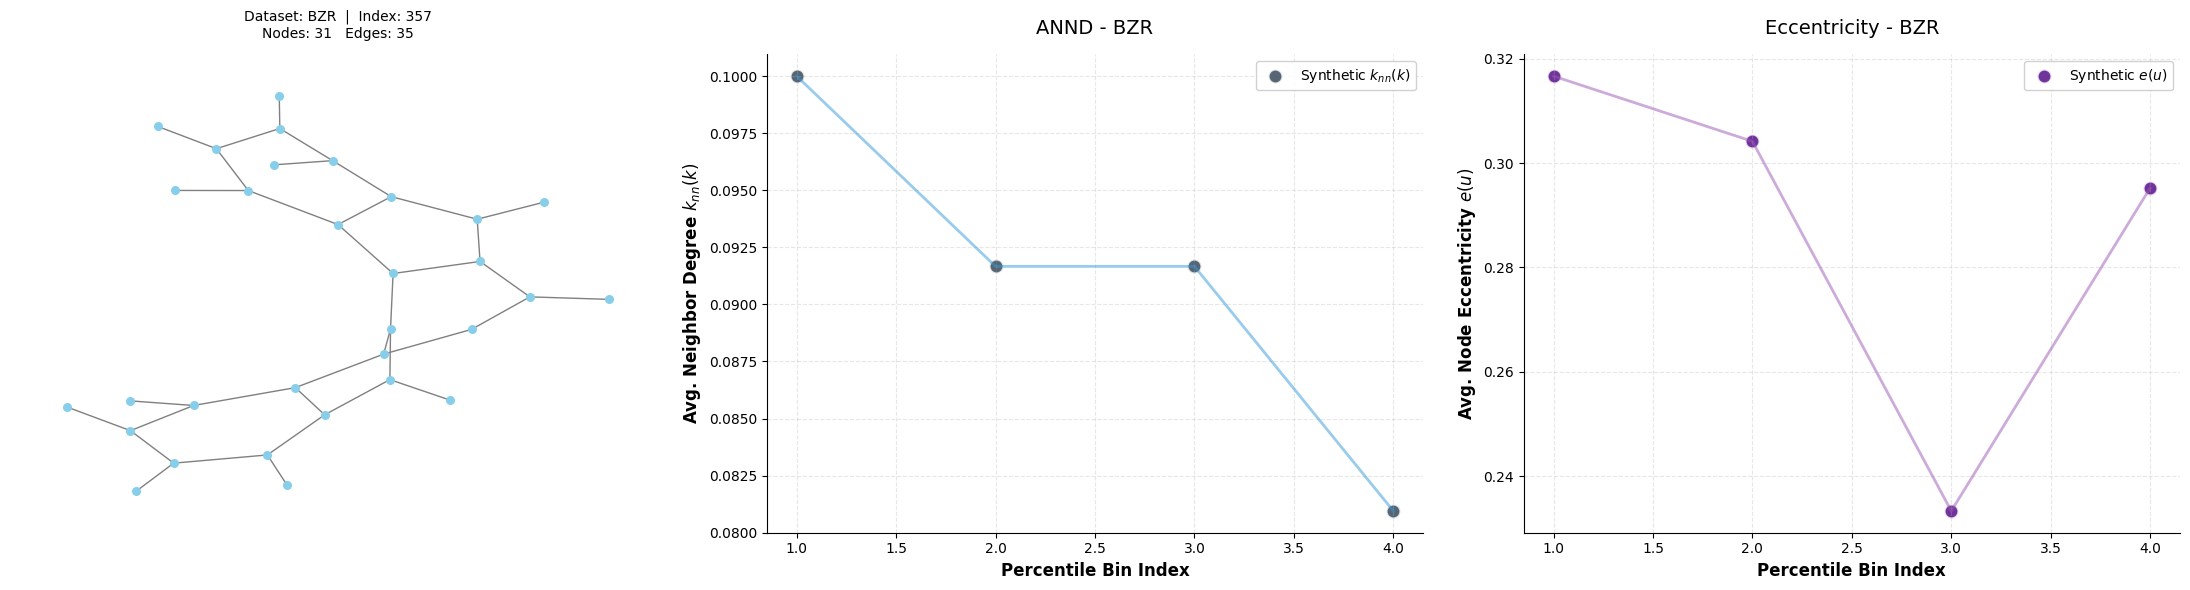

In [3]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 6))

plot_graph(graph=GRAPH_NX, ax=ax1, dataset_name=f"{DATASET}", graph_index=IDX)
plot_annd(graph=GRAPH_NX, ax=ax2, title=f"ANND - {DATASET}")
plot_eccentricity(graph=GRAPH_NX, ax=ax3, title=f"Eccentricity - {DATASET}")

# Calculate and print assortativity
target_stats = analyze_single_graph(GRAPH_IG)

plt.tight_layout()
plt.show()

Initial ANND:                            [0.08333333 0.09722222 0.0875     0.08571429]
Target ANND:                             [0.1        0.09166667 0.09166667 0.08095238]
Initial assortativity:                   -0.006051437216338955
Target assortativity:                    -0.2179
Initial ANND error:                      0.072023
Accepted improvement at step 1: error = 0.0575, annd_vector = [0.08333333 0.09722222 0.0875     0.08571429]
Accepted improvement at step 2: error = 0.0456, annd_vector = [0.08333333 0.09722222 0.0875     0.08571429]
Accepted improvement at step 3: error = 0.0358, annd_vector = [0.1        0.09444444 0.08472222 0.08571429]
Accepted improvement at step 4: error = 0.0199, annd_vector = [0.1        0.09166667 0.0875     0.08571429]
Accepted improvement at step 5: error = 0.0185, annd_vector = [0.1        0.09166667 0.0875     0.08571429]
Accepted improvement at step 6: error = 0.0151, annd_vector = [0.1        0.09166667 0.09027778 0.08253968]
Accepted improve

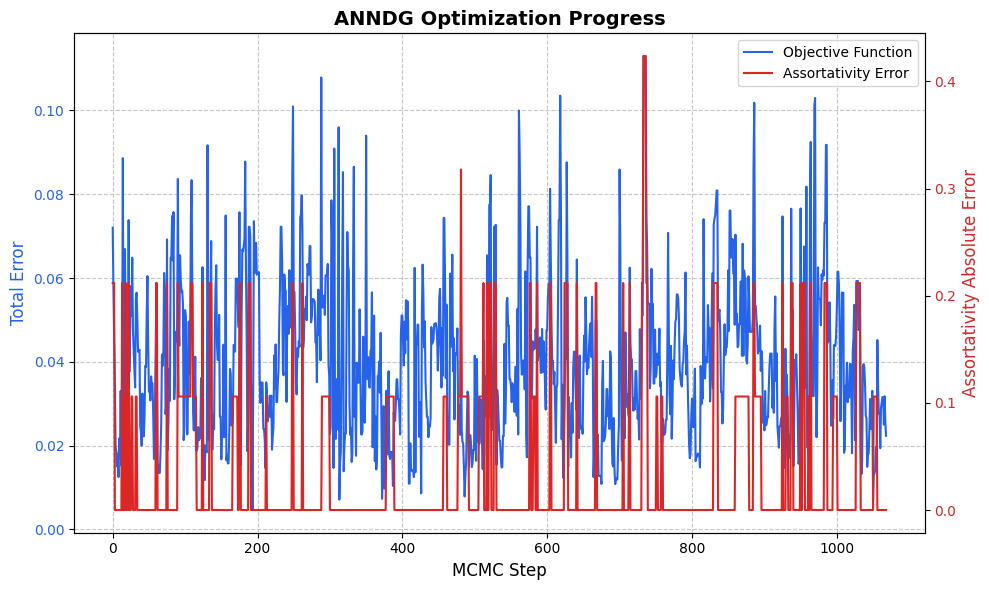

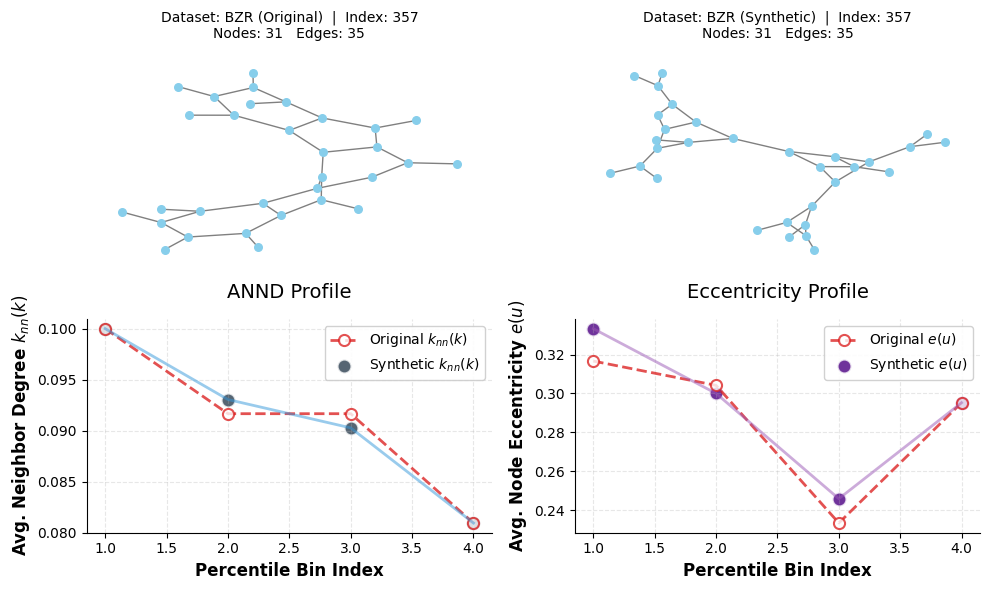


TOPOLOGICAL STATISTIC     | ORIGINAL     | SYNTHETIC    | DELTA     
----------------------------------------------------------------------
Assortativity             |      -0.2179 |      -0.2179 |     0.0000
Modularity                |       0.5694 |       0.6343 |     0.0649
Clustering                |       0.0000 |       0.0000 |     0.0000
Efficiency                |       0.3052 |       0.2905 |     0.0147
Diameter                  |      11.0000 |      11.0000 |     0.0000
----------------------------------------------------------------------
ANND Bin 0                |       0.1000 |       0.1000 |     0.0000
ANND Bin 1                |       0.0917 |       0.0931 |     0.0014
ANND Bin 2                |       0.0917 |       0.0903 |     0.0014
ANND Bin 3                |       0.0810 |       0.0810 |     0.0000
----------------------------------------------------------------------

STRUCTURAL ERROR SUMMARY  | VALUE       
----------------------------------------
Moments Error

In [7]:
# Analyze Original Graph
target_stats = analyze_single_graph(GRAPH_IG)

# Generate and Analyze Synthetic Graph
rng = np.random.default_rng(seed=5)
GRAPH_SYNTH_NX, info = generate_graph(target_stats, rng=rng, debug=True, replicate_eccentricity=True)
GRAPH_SYNTH_IG = networkx_to_igraph(GRAPH_SYNTH_NX)
obtained_stats = analyze_single_graph(GRAPH_SYNTH_IG)

# Combined Visualization
fig, axes = plt.subplots(2, 2, figsize=(10, 6))

# Row 1: Graph Structures
plot_graph(graph=GRAPH_NX, ax=axes[0, 0], dataset_name=f"{DATASET} (Original)", graph_index=IDX)
plot_graph(graph=GRAPH_SYNTH_NX, ax=axes[0, 1], dataset_name=f"{DATASET} (Synthetic)", graph_index=IDX)

# Row 2: Topological Metrics
plot_annd(annd_values=info['best_annd'], ax=axes[1, 0], title="ANND Profile", target_graph=GRAPH_NX)
plot_eccentricity(ecc_values=info['best_eccentricity'], ax=axes[1, 1], title="Eccentricity Profile", target_graph=GRAPH_NX)

plt.tight_layout()
plt.show()

print(f"\n" + "="*70)
print(f"{'TOPOLOGICAL STATISTIC':<25} | {'ORIGINAL':<12} | {'SYNTHETIC':<12} | {'DELTA':<10}")
print("-" * 70)

# Scalar metrics comparison
scalar_metrics = ['assortativity', 'modularity', 'clustering', 'efficiency', 'diameter']
for m in scalar_metrics:
    orig = target_stats.get(m, 0.0)
    synth = obtained_stats.get(m, 0.0)
    delta = abs(orig - synth)
    print(f"{m.capitalize():<25} | {orig:>12.4f} | {synth:>12.4f} | {delta:>10.4f}")

# ANND comparison
print("-" * 70)
print(f"{'ANND Bin 0':<25} | {target_stats['annd'][0]:>12.4f} | {info['best_annd'][0]:>12.4f} | {abs(target_stats['annd'][0] - info['best_annd'][0]):>10.4f}")
print(f"{'ANND Bin 1':<25} | {target_stats['annd'][1]:>12.4f} | {info['best_annd'][1]:>12.4f} | {abs(target_stats['annd'][1] - info['best_annd'][1]):>10.4f}")
print(f"{'ANND Bin 2':<25} | {target_stats['annd'][2]:>12.4f} | {info['best_annd'][2]:>12.4f} | {abs(target_stats['annd'][2] - info['best_annd'][2]):>10.4f}")
print(f"{'ANND Bin 3':<25} | {target_stats['annd'][3]:>12.4f} | {info['best_annd'][3]:>12.4f} | {abs(target_stats['annd'][3] - info['best_annd'][3]):>10.4f}")
print("-" * 70)

annd_error = calculate_annd_error(info['best_annd'], target_stats['annd'])
ecc_error = calculate_eccentricity_error(info['best_eccentricity'], target_stats['eccentricity'])
moments_error = calculate_moments_error(target_stats['normalized_degree_moments'], obtained_stats['normalized_degree_moments'])
diameter_error = abs(obtained_stats['diameter'] - target_stats['diameter']) / target_stats['diameter'] if target_stats['diameter'] > 0 else 0.0

print(f"\n{'STRUCTURAL ERROR SUMMARY':<25} | {'VALUE':<12}")
print("-" * 40)
print(f"{'Moments Error':<25} | {moments_error:>12.4f}")
print(f"{'ANND Error':<25} | {annd_error:>12.4f}")
print(f"{'Eccentricity Error':<25} | {ecc_error:>12.4f}")
print(f"{'Diameter Error':<25} | {diameter_error:>12.4f}")
print("="*70 + "\n")